In [ ]:
# Extra libraries installed in /scratch
import sys
sys.path.insert(0, '/scratch/network/ih2422/lib')

# Importing functions from other files
from narratives_prep import *
from claude_api_key import *

# Authenticate with the API key
api_key = load_vault()

Vault unlocked — ANTHROPIC_API_KEY set.


In [19]:
twenty_audio = fetch_audio("21styear")
tunnel_audio = fetch_audio("tunnel")

In [25]:
twenty_transcript = fetch_transcript("21styear")
tunnel_transcript = fetch_transcript("tunnel")

In [26]:
twenty_transcript

'This is Los Angeles. And it\'s the height of summer. In a small bungalow off of La Cienega, Clara serves homemade chili and chips in red plastic bowls -- wine in blue plastic. The colors don\'t match and the cups are too big to serve wine. "You didn\'t get half the things on my list," she hisses at Gary as he passes. He shrugs. No one seems to mind but her. "Did you have to buy a four-hundred dollar bottle of Scotch?" Gary waves away her upset. He seems distracted. Guilty of something. She can tell by the way he avoids her. Clara looks at her face in the hallway mirror. She\'s thirty-three years old. She\'s slowly getting white hairs in her eyebrows. She feels completely alone. Grad students fill the low-ceiling space, chewing big words and gesticulating emphatically. Gary\'s face looks up from the photo his parents have framed in expensive mahogany: Elated, graduating, cap and gown and all. Toasts and more toasts: "To our Doctor of Philosophy. Amazing Art Prodigy. To Gary Loisin!" Cl

### 1. Place Annotation (with Claude)

In [31]:
import csv
import json
import anthropic
from pathlib import Path

out_dir = Path(".")

def annotate_places(story_name, transcript, valid_places, out_path):
    if out_path.exists():
        print(f"{out_path.name} already exists — skipping API call.")
        with open(out_path) as f:
            return list(csv.DictReader(f, delimiter="\t"))

    client = anthropic.Anthropic()
    labels_str = ", ".join(f'"{p}"' for p in valid_places)

    prompt = f"""You are analyzing the story "{story_name}".

Step 1 — Segment: Divide the full transcript into contiguous segments, each covering a single scene or location. For every segment, assign one of these place labels: {labels_str}, or "other" for anything that does not clearly belong to one of these places.

Step 2 — List all segments in their original story order as a JSON array, including "other" segments. Each element must be:
  {{"place": "<label>", "excerpt": "<one or more full sentences from the transcript that represent this segment>"}}

Rules:
- Do not reorder segments.
- Excerpts must be full sentences taken directly from the transcript. No ellipses.
- The same place label may appear many times if it recurs in the story.

Output ONLY the JSON array, no markdown fences.

Transcript:
{transcript}"""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=16000,
        thinking={"type": "enabled", "budget_tokens": 10000},
        messages=[{"role": "user", "content": prompt}]
    )

    text = next(b.text for b in response.content if b.type == "text").strip()
    if text.startswith("```"):
        text = text.split("```")[1]
        if text.startswith("json"):
            text = text[4:]

    rows = json.loads(text)
    with open(out_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["place", "excerpt"], delimiter="\t")
        writer.writeheader()
        writer.writerows(rows)

    place_counts = {p: sum(1 for r in rows if r["place"] == p) for p in valid_places + ["other"]}
    print(f"Saved {out_path.name} — {len(rows)} rows: {place_counts}")
    return rows

tunnel_places = annotate_places(
    "Tunnel Under the World", tunnel_transcript,
    ["guy_home", "bus", "office"],
    out_dir / "tunnel_places.tsv"
)
twenty_places = annotate_places(
    "21st Year", twenty_transcript,
    ["clara_home", "steven_home", "cab"],
    out_dir / "twenty_places.tsv"
)

Saved tunnel_places.tsv — 12 rows: {'guy_home': 3, 'bus': 3, 'office': 2, 'other': 4}
Saved twenty_places.tsv — 51 rows: {'clara_home': 12, 'steven_home': 12, 'cab': 2, 'other': 25}


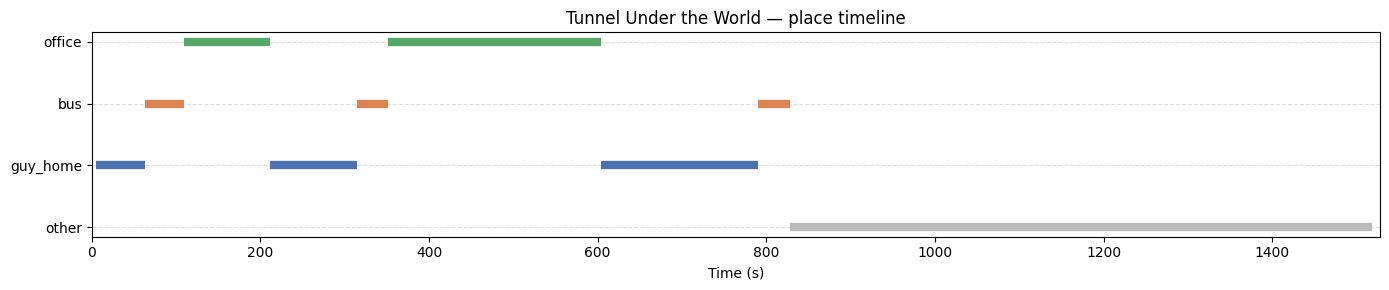

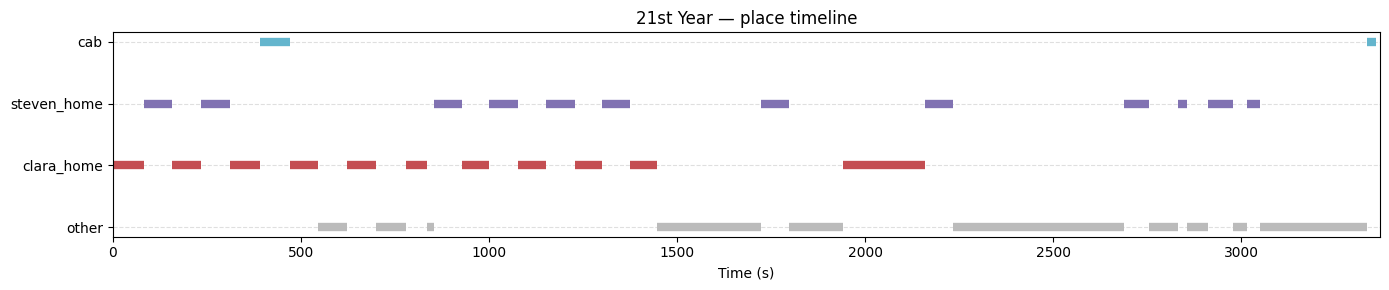

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path

def align_tsv_to_whisperx(tsv_path, segments, transcript):
    """
    Match each TSV excerpt to the original transcript to get a character position,
    then map linearly to time. Scans forward from the previous match to handle repetition.
    End time = next row's start time.
    """
    total_duration = segments[-1]["end"]
    total_chars    = len(transcript)

    rows_raw = list(csv.DictReader(open(tsv_path), delimiter="\t"))

    cursor = 0
    rows = []
    for row in rows_raw:
        key = row["excerpt"].strip()[:60]
        pos = transcript.find(key, cursor)
        if pos == -1:
            # Try shorter key
            pos = transcript.find(key[:30], cursor)
        if pos == -1:
            print(f"  [no match] {key}")
            rows.append({"place": row["place"], "start": None})
        else:
            t = (pos / total_chars) * total_duration
            rows.append({"place": row["place"], "start": t})
            cursor = pos + 1

    rows = [r for r in rows if r["start"] is not None]
    for i in range(len(rows) - 1):
        rows[i]["end"] = rows[i + 1]["start"]
    rows[-1]["end"] = total_duration
    return rows

def plot_place_line(aligned_rows, title, place_order, place_colors):
    label_to_y = {p: i for i, p in enumerate(place_order)}
    label_to_y["other"] = -1

    fig, ax = plt.subplots(figsize=(14, 3))
    for row in aligned_rows:
        y = label_to_y.get(row["place"], -1)
        color = place_colors.get(row["place"], "#aaaaaa")
        ax.plot([row["start"], row["end"]], [y, y], color=color, linewidth=6, solid_capstyle="butt")

    ax.set_yticks([-1] + list(range(len(place_order))))
    ax.set_yticklabels(["other"] + place_order)
    ax.set_xlabel("Time (s)")
    ax.set_title(title)
    ax.set_xlim(left=0, right=aligned_rows[-1]["end"] + 10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

tunnel_colors = {"guy_home": "#4C72B0", "bus": "#DD8452", "office": "#55A868", "other": "#bbbbbb"}
twenty_colors  = {"clara_home": "#C44E52", "steven_home": "#8172B2", "cab": "#64B5CD", "other": "#bbbbbb"}

tunnel_aligned = align_tsv_to_whisperx(Path("tunnel_places.tsv"), tunnel_segments, tunnel_transcript)
twenty_aligned = align_tsv_to_whisperx(Path("twenty_places.tsv"), twenty_segments, twenty_transcript)

plot_place_line(tunnel_aligned, "Tunnel Under the World — place timeline",
                ["guy_home", "bus", "office"], tunnel_colors)
plot_place_line(twenty_aligned, "21st Year — place timeline",
                ["clara_home", "steven_home", "cab"], twenty_colors)

### Single-Subject Analysis: Tunnel Story